In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
import yaml
import numpy as np
from scipy.stats import norm
from statsmodels.stats.proportion import proportions_ztest

In [27]:
with open('../config.yaml', 'r') as file:
    config = yaml.safe_load(file)

In [28]:
# import the datasets
df = pd.read_csv(config["output_data"]["file5"])

In [29]:
# drop unamed
df = df.drop(columns=['Unnamed: 0'])
df.shape

(239985, 14)

## Ordering values

In [30]:
# sort values
df = df.sort_values(by=['client_id', 'visit_id', 'date_time'], ascending=True)
df.head(5)

,client_id,visitor_id,visit_id,process_step,date_time,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth,Variation
70440,555,402506806_56087378777,637149525_38041617439_716659,start,2017-04-15 12:57:56,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,Test
70439,555,402506806_56087378777,637149525_38041617439_716659,step_1,2017-04-15 12:58:03,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,Test
70438,555,402506806_56087378777,637149525_38041617439_716659,step_2,2017-04-15 12:58:35,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,Test
70437,555,402506806_56087378777,637149525_38041617439_716659,step_3,2017-04-15 13:00:14,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,Test
70436,555,402506806_56087378777,637149525_38041617439_716659,confirm,2017-04-15 13:00:34,3.0,46.0,29.5,U,2.0,25454.66,2.0,6.0,Test


## Keep first start and last confirm

In [31]:
# Sort by visit_id and date_time to ensure chronological order
df = df.sort_values(['visit_id', 'date_time'])

# Compare each start with the previous row in the same visit
df['prev_step'] = df.groupby('visit_id')['process_step'].shift(1)

# Keep rows:
# - all non-start steps, OR
# - first start in a consecutive sequence
df = df[
    (df['process_step'] != 'start') | 
    ((df['process_step'] == 'start') & (df['prev_step'] != 'start'))
]

# Drop helper column
df = df.drop(columns=['prev_step'])

# Reset index for clean DataFrame
df = df.reset_index(drop=True)

In [32]:
# Sort by visit_id and date_time
df = df.sort_values(['visit_id', 'date_time'])

# Compare each confirm with the next row in the same visit
df['next_step'] = df.groupby('visit_id')['process_step'].shift(-1)

# Keep rows:
# - all non-confirm steps, OR
# - last confirm in a consecutive sequence (next_step != confirm)
df = df[
    (df['process_step'] != 'confirm') |
    ((df['process_step'] == 'confirm') & (df['next_step'] != 'confirm'))
]

# Drop helper column
df = df.drop(columns=['next_step'])

# Reset index for a clean DataFrame
df = df.reset_index(drop=True)

## Mapping steps and calculate difference

In [33]:
# mapping step to integer to calculate difference between steps
step_mapping = {
    'start': 0,
    'step_1': 1,
    'step_2': 2,
    'step_3': 3,
    'confirm': 4
}

# create a new column step to map step 1 = 1...
df['step'] = df['process_step'].map(step_mapping)

# create a next step column and retrieve 1 step 
df['next_step'] = df.groupby(['visit_id'])['step'].shift(-1)

# calculate the difference
df['step_diff'] = df['next_step']- df['step']

In [23]:
df_steps_clean = df[['visit_id','process_step','step_diff','Variation']]

df_steps_clean = df_steps_clean[df_steps_clean['process_step'] != 'confirm']

df_steps_clean['step_diff'] = np.where(
    df_steps_clean['step_diff'].isna(),        # si vide (NaN)
    0,                        # garde NaN
    np.where(df_steps_clean['step_diff'] == 1, 1, 0)  # si == 1 → 1 sinon 0
)
df_steps_clean = df_steps_clean.rename(columns={'step_diff': 'completed'})
df_steps_clean.to_csv("kp1_steps.csv")

## CONTROL COMPLETION RATE

In [34]:
# remove confirm (at there is no other step after so it does not need to be achieved)

df_control = df[df['Variation'] == 'Control']

kp1_by_step_control = df_control[df_control['process_step'] !='confirm']

# group by process_step
kp1_by_step_control = kp1_by_step_control.groupby('process_step').agg(
    total=('process_step', 'size'),           # total number of rows of step1 for ex
    count_step=('step_diff', lambda x: (x == 1).sum())  # number of times step_diff == 1 per step
)

# calculate completion rate per step
kp1_by_step_control['pct_step_control'] = round(kp1_by_step_control['count_step'] / kp1_by_step_control['total']*100,0)

kp1_by_step_control


,total,count_step,pct_step_control
process_step,,,
start,25418,18482,73.0
step_1,21061,16299,77.0
step_2,19058,16109,85.0
step_3,17000,11311,67.0


In [35]:
# list of the correct sequence
funnel = ['start', 'step_1', 'step_2', 'step_3', 'confirm']

# function to check if the sequence exsits in a visit
def has_complete_funnel(visit_df):
    # sort the visit chronologically
    steps = visit_df.sort_values('date_time')['process_step'].tolist()
    
    funnel_index = 0  # pointer to track position in funnel
    for step in steps:
        if step == funnel[funnel_index]:
            funnel_index += 1
            if funnel_index == len(funnel):  # all steps found
                return True
    return False  # funnel not complete

# per visit_id
funnel_per_visit_control = df_control.groupby('visit_id').apply(has_complete_funnel).reset_index()
funnel_per_visit_control.columns = ['visit_id', 'completed_process']

funnel_per_visit_control["group"] = "Control"
funnel_per_visit_control

,visit_id,completed_process,group
0,100030127_47967100085_936361,False,Control
1,100037962_47432393712_705583,False,Control
2,100057941_88477660212_944512,False,Control
3,10006594_66157970412_679648,True,Control
4,100071743_53464757454_616703,False,Control
...,...,...,...
23317,999859408_41720215615_938916,True,Control
23318,999890184_77121766521_746360,False,Control
23319,999936732_27995195904_324897,False,Control
23320,999951892_54774917180_163890,False,Control


In [36]:
# calculate number of visits that have at least one completed sequence (from start to confirm without errors)
num_true = funnel_per_visit_control['completed_process'].value_counts()[True]
control_completion_rate = round((num_true / len(funnel_per_visit_control['completed_process']))*100,2)
control_completion_rate

np.float64(46.85)

## TEST COMPLETION RATE

In [37]:
# remove confirm (at there is no other step after so it does not need to be achieved)

df_test = df[df['Variation'] == 'Test']

kp1_by_step_test = df_test[df_test['process_step'] !='confirm']

# group by process_step
kp1_by_step_test = kp1_by_step_test.groupby('process_step').agg(
    total=('process_step', 'size'),           # total number of rows of step1 for ex
    count_step=('step_diff', lambda x: (x == 1).sum())  # number of times step_diff == 1 per step
)

# calculate completion rate per step
kp1_by_step_test['pct_step_test'] = round(kp1_by_step_test['count_step'] / kp1_by_step_test['total']*100,0)

kp1_by_step_test

,total,count_step,pct_step_test
process_step,,,
start,33971,26519,78.0
step_1,30684,21959,72.0
step_2,24664,19528,79.0
step_3,20732,14742,71.0


In [38]:
# list of the correct sequence
funnel = ['start', 'step_1', 'step_2', 'step_3', 'confirm']

# function to check if the sequence exsits in a visit
def has_complete_funnel(visit_df):
    # sort the visit chronologically
    steps = visit_df.sort_values('date_time')['process_step'].tolist()
    
    funnel_index = 0  # pointer to track position in funnel
    for step in steps:
        if step == funnel[funnel_index]:
            funnel_index += 1
            if funnel_index == len(funnel):  # all steps found
                return True
    return False  # funnel not complete

# per visit_id
funnel_per_visit_test = df_test.groupby('visit_id').apply(has_complete_funnel).reset_index()
funnel_per_visit_test.columns = ['visit_id', 'completed_process']

funnel_per_visit_test["group"] = "Test"
funnel_per_visit_test

,visit_id,completed_process,group
0,100012776_37918976071_457913,False,Test
1,100019538_17884295066_43909,True,Test
2,100173292_91322748906_143563,True,Test
3,100217156_67053490690_383412,True,Test
4,100221419_95702886123_228743,False,Test
...,...,...,...
28764,999960019_60838685252_926860,False,Test
28765,999971096_28827267783_236076,True,Test
28766,999976049_95772503197_182554,True,Test
28767,999984454_18731538378_781808,True,Test


In [40]:
# calculate number of visits that have at least one completed sequence (from start to confirm without errors)
num_true = funnel_per_visit_test['completed_process'].value_counts()[True]
test_completion_rate = round((num_true / len(funnel_per_visit_test['completed_process']))*100,2)
test_completion_rate

np.float64(49.74)

In [41]:
# get a file of completed / not completed visits
concat_visits = pd.concat([funnel_per_visit_test,funnel_per_visit_control], axis =0, join = "outer")
concat_visits.to_csv("kp1_visits.csv")

In [42]:
# merge Control et Test by process_step
KP1_steps = kp1_by_step_control.merge(
    kp1_by_step_test,
    on='process_step',
    suffixes=('_Control', '_Test')
)
KP1_steps

,total_Control,count_step_Control,pct_step_control,total_Test,count_step_Test,pct_step_test
process_step,,,,,,
start,25418,18482,73.0,33971,26519,78.0
step_1,21061,16299,77.0,30684,21959,72.0
step_2,19058,16109,85.0,24664,19528,79.0
step_3,17000,11311,67.0,20732,14742,71.0


In [43]:
# Graph to visualize steps per group
KP1_steps_g  = pd.DataFrame(KP1_steps[['pct_step_control','pct_step_test']]).reset_index()
KP1_steps_g.columns

Index(['process_step', 'pct_step_control', 'pct_step_test'], dtype='str')

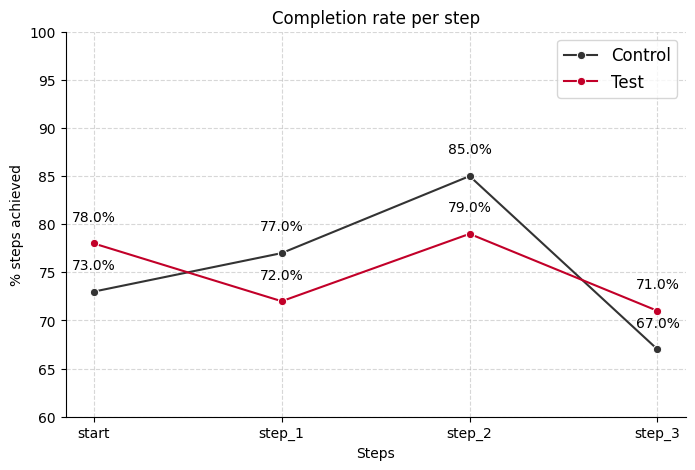

In [44]:
# Plotting a line graph to visualize the trend of average 'SalePrice' across different 'YearBuilt'
# long format
df_long = KP1_steps_g.melt(id_vars="process_step", 
                  value_vars=["pct_step_control", "pct_step_test"],
                  var_name="group", 
                  value_name="pct")

# Rename
df_long['group'] = df_long['group'].replace({
    'pct_step_control': 'Control',
    'pct_step_test': 'Test'
})

custom_palette = {
    "Control": "#333333",
    "Test": "#C20029"
}

# Line plot
plt.figure(figsize=(8,5))
sns.lineplot(data=df_long, x="process_step", y="pct", hue="group", marker="o", palette = custom_palette)
sns.despine()

# Custom
plt.title("Completion rate per step")
plt.xlabel("Steps")
plt.ylabel("% steps achieved")
plt.ylim(60, 100)
for i, row in df_long.iterrows():
    plt.text(row['process_step'], row['pct']+2, f"{row['pct']}%", ha='center', va='bottom')
plt.grid(True,linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.savefig(r"C:\Users\Utilisateur\Desktop\IRONHACK_DA\COURSES\week-5\vanguard-ab-test\figures\g_CmpltnRt_Stp.png")
plt.show()

In [45]:
print(f" Completion rate for Control Group is: {control_completion_rate} %")
print(f" Completion rate for Test Group is: {test_completion_rate} %")

 Completion rate for Control Group is: 46.85 %
 Completion rate for Test Group is: 49.74 %


C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_11900\682706276.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="group", y="pct", palette=palette, order=["Control","Test"])


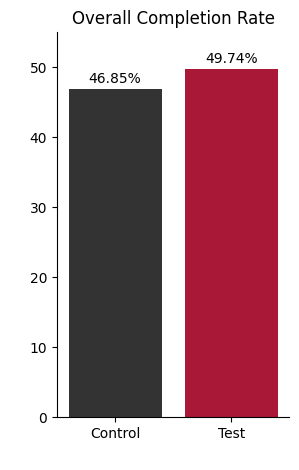

In [46]:
# Kepp the data
df = pd.DataFrame({
    "group": ["Control", "Test"],
    "pct": [46.85, 49.74]
})


palette = {"Control": "#333333","Test": "#C20029"}

# Bar plot
plt.figure(figsize=(3,5))
sns.barplot(data=df, x="group", y="pct", palette=palette, order=["Control","Test"])

# Ajouter valeurs au-dessus des barres
for i, row in df.iterrows():
    plt.text(i, row['pct']+0.5, f"{row['pct']}%", ha='center', va='bottom')

# Titres et axes
plt.title("Overall Completion Rate", fontsize=12)
plt.ylabel(" ")
plt.xlabel(" ")
plt.ylim(0, 55)
sns.despine()  # supprime la bordure supérieure et droite
plt.savefig(r"C:\Users\Utilisateur\Desktop\IRONHACK_DA\COURSES\week-5\vanguard-ab-test\figures\g_CmpltnRt_Grp.png")
plt.show()

In [68]:
def show_statistical_test(statistic: float, alpha: float, n: int, distribution: str=["t-student","normal"], alternative: str=["two-sided","lower","greater"]):

    if distribution not in ["t-student","normal"]:
        raise TypeError("Sorry, only 't-student', and 'normal' distributions are acepted")

    if alternative not in ["two-sided","lower","greater"]:
        raise TypeError("Sorry, only 'two-sided', 'lower', and 'greated' are acepted valued for the alternative")

    if not isinstance(statistic, float):
        raise TypeError("Sorry, the data type for the statistic must be float")

    if not isinstance(alpha, float):
        raise TypeError("Sorry, the data type for alpha must be float")

    if not isinstance(n, int):
        raise TypeError("Sorry, the data type for n must be int")

    x_values = np.linspace(-3, 3)

    if distribution == "t-student":

        y_values = st.t.pdf(x_values, df=n-1)

        if alternative == "two-sided": # Computing the critical values

            lower_critical_value = st.t.ppf(alpha/2, df=n-1)
            upper_critical_value = st.t.ppf(1-(alpha/2), df=n-1)

            x_values1 = np.linspace(-3, lower_critical_value)
            y_values1 = st.t.pdf(x_values1, df=n-1)

            x_values2 = np.linspace(upper_critical_value, 3)
            y_values2 = st.t.pdf(x_values2, df=n-1)

        elif alternative == "lower":

            critical_value = st.t.ppf(alpha, df=n-1)

            x_values1 = np.linspace(-3, critical_value)
            y_values1 = st.t.pdf(x_values1, df=n-1)

        elif alternative == "greater":

            critical_value = st.t.ppf(1-alpha, df=n-1)

            x_values2 = np.linspace(critical_value, 3)
            y_values2 = st.t.pdf(x_values2, df=n-1)

    elif distribution == "normal":

        y_values = st.norm.pdf(x_values)

        if alternative == "two-sided": # Computing the critical values

            lower_critical_value = st.norm.ppf(alpha/2)
            upper_critical_value = st.norm.ppf(1-(alpha/2))

            x_values1 = np.linspace(-3, lower_critical_value)
            y_values1 = st.norm.pdf(x_values1)

            x_values2 = np.linspace(upper_critical_value, 3)
            y_values2 = st.norm.pdf(x_values2)

        elif alternative == "lower":

            critical_value = st.norm.ppf(alpha)

            x_values1 = np.linspace(-3, critical_value)
            y_values1 = st.norm.pdf(x_values1)

        elif alternative == "greater":

            critical_value = st.norm.ppf(1-alpha)

            x_values2 = np.linspace(critical_value, 3)
            y_values2 = st.norm.pdf(x_values2)

    df = pd.DataFrame({"x": x_values, "pdf": y_values})

    title = f"{distribution} Probability Density Function"

    fig = px.line(df, x="x", y="pdf", title=title)

    if alternative == "two-sided":

        fig.add_vline(x=lower_critical_value, line_color="red")
        fig.add_vline(x=upper_critical_value, line_color="red")

        fig.add_annotation(x=lower_critical_value,y=0,text=f"Lower critical value {lower_critical_value: .2f}",xref="x",yref="paper",yanchor="bottom")
        fig.add_annotation(x=upper_critical_value,y=0,text=f"Upper critical value {upper_critical_value: .2f}",xref="x",yref="paper",yanchor="bottom")

        fig.add_scatter(x=x_values1, y=y_values1,fill='tozeroy', mode='none' , fillcolor='red')
        fig.add_scatter(x=x_values2, y=y_values2,fill='tozeroy', mode='none' , fillcolor='red')

    elif alternative == "lower":

        fig.add_vline(x=critical_value, line_color="red")
        fig.add_annotation(x=critical_value,y=0,text=f"Critical value {critical_value: .2f}",xref="x",yref="paper",yanchor="bottom")

        fig.add_scatter(x=x_values1, y=y_values1,fill='tozeroy', mode='none' , fillcolor='red')

    elif alternative == "greater":

        fig.add_vline(x=critical_value, line_color="red")
        fig.add_annotation(x=critical_value,y=0,text=f"Critical value {critical_value: .2f}",xref="x",yref="paper",yanchor="bottom")

        fig.add_scatter(x=x_values2, y=y_values2,fill='tozeroy', mode='none' , fillcolor='red')

    fig.add_vline(x=statistic)
    fig.add_annotation(x=statistic,y=0,text=f"Statistic {statistic: .2f}",xref="x",yref="paper",yanchor="bottom")

    fig.update_layout(title_text=f'{distribution} Probability Density Function', title_x=0.5)

    fig.update_layout(showlegend=False)

    fig.show()
    return fig

In [64]:
# Check if there is a significant difference between the 2 overall completion rates

# 1. Statistical test comparing the Control and Test completion rates: z-proportions between 2 samples
# 2. Significance level (alpha): 0.05
# 3. HO: Null hypothesis: Control = Test
#    H1: Alternative hypothesis: Control != Test

# 4. Get your sample: Contingency table of number of True/False completed visits per group
    # concatenate the 2 groups
completion_tab = pd.concat([funnel_per_visit_control, funnel_per_visit_test], axis=0, join="outer")
completion_tab = completion_tab[["completed_process","group"]].reset_index(drop=True)

    # create a contingency table to visualize the total true on total
contingency_table = pd.crosstab(completion_tab['group'], completion_tab['completed_process'], margins = True, margins_name ="Total")
pd.DataFrame(contingency_table)

# Sample data (from the contingency table)
count = [10926, 14311]  # Number of successes in both samples
nobs = [23332, 28769]  # Number of observations in both samples

# 5. Compute the test statistic based on your sample
z, p_value = proportions_ztest(count, nobs)

# 6. Solve the statistical test:
print(contingency_table)
print(print(f'Statistic: {z}, p-value: {p_value}'))

alpha = 0.05
if p_value > alpha:
    print("We are not able to reject the null hypothesis")
else:
    print("We reject the null hypotesis")

completed_process  False   True  Total
group                                 
Control            12396  10926  23322
Test               14458  14311  28769
Total              26854  25237  52091
Statistic: -6.623134106524944, p-value: 3.516617038847482e-11
None
We reject the null hypotesis


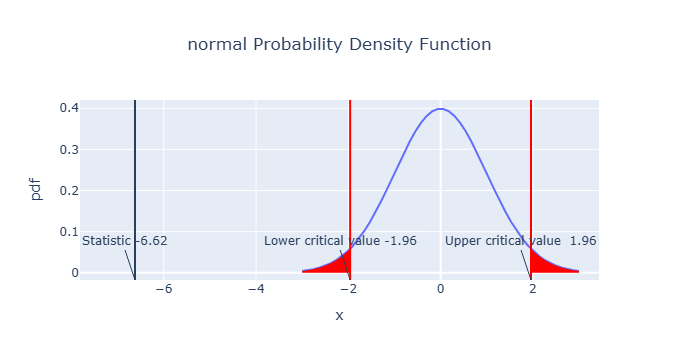

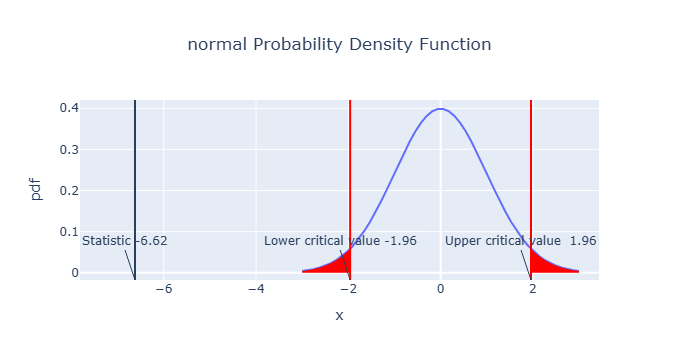

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


In [69]:
import numpy as np
import pandas as pd
import plotly.express as px
import scipy.stats as st

# récupérer le graphique dans une variable
show_statistical_test(
    statistic=float(z),
    alpha=0.05,
    n=sum(nobs),  # ou juste un entier
    distribution="normal",
    alternative="two-sided"
)


In [77]:
# Check if there is an increase of 5% in test completion rate 

# we follow the same statistical test z-proportions between 2 samples
# H0: Null hypothesis: Test >= Control + 0.05
# H1: Alternative hypothesis Test < Control + 0.05

# Same as
# H0: Test - Control >= 0.05 (ie 5 because 5%)
# H1: Test - Control < 0.05 ((ie 5 because 5%)
# --- data ---
count = [10926, 14311]  # Control, Test
nobs = [23332, 28769]

p_control = count[0] / nobs[0]
p_test = count[1] / nobs[1]

delta = 0.05  # delta H0
alpha = 0.05  # confidence level

# --- Z-test H1: Test - Control < delta ---
var_control = p_control * (1 - p_control)
var_test = p_test * (1 - p_test)

z_stat = ((p_test - p_control) - delta) / np.sqrt(var_test/nobs[1] + var_control/nobs[0])
p_value = st.norm.cdf(z_stat)  # "less"

# --- Results ---
print(f"Control proportion: {p_control:.4f}")
print(f"Test proportion: {p_test:.4f}")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value (H1: Test - Control < delta): {p_value:.4f}")

# --- Final ---
if p_value < alpha:
    print(f"p-value < {alpha}, we reject the null hypothesis H0 : Test - Control < delta")
else:
    print(f"p-value ≥ {alpha}, we can't reject H0")

Control proportion: 0.4683
Test proportion: 0.4974
Z-statistic: -4.7359
P-value (H1: Test - Control < delta): 0.0000
p-value < 0.05, we reject the null hypothesis H0 : Test - Control < delta


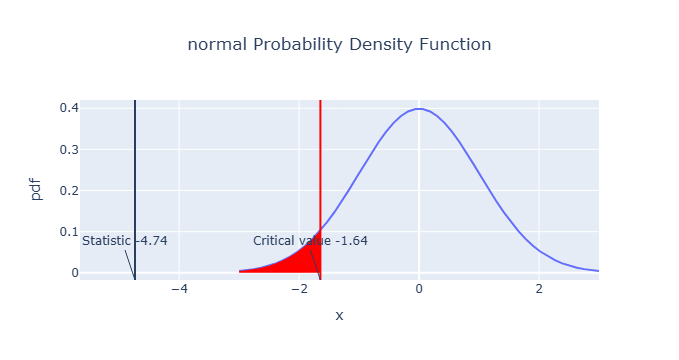

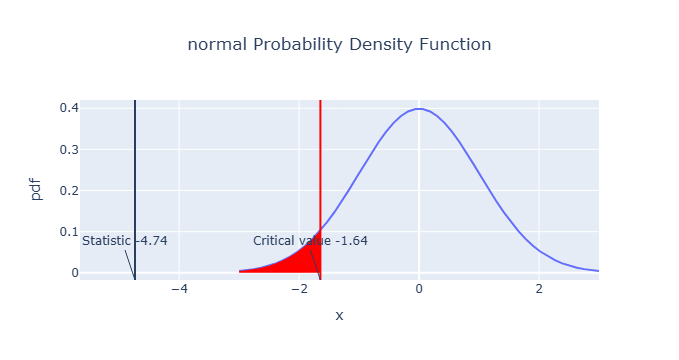

In [78]:
show_statistical_test(
    statistic=float(z_stat),
    alpha=0.05,
    n=sum(nobs),
    distribution="normal",
    alternative="lower"  

# A/B Testing Presentation

**1. Client Selection**  
- Total initial clients: 70,609  
- Clients selected for A/B testing: 50,500  

| Group    | Number of clients | % of selected clients |
|----------|-----------------|----------------------|
| Control  | 23,532           | 46.6 %               |
| Test     | 26,968           | 53.4 %               |

> The distribution is slightly imbalanced (46.6 % vs 53.4 %) but remains **close to 50/50**, which is acceptable for randomization.

**2. Participating Clients**  
- Clients who participated: 40,028  

| Group    | Number of clients | % of total participants |
|----------|-----------------|------------------------|
| Control  | 18,016           | 45.0 %                 |
| Test     | 22,012           | 55.0 %                 |

> The proportion of participants is consistent with the initial distribution and **indicates that randomization is generally respected**.

**3. Unique Visits**  
- Total unique visits (visit_id): 51,998 from 15th March to 30th April 2017.  
- Observed distribution by group:

| Group    | Number of visits | % of total visits |
|----------|-----------------|-----------------|
| Control  | 23,323           | 44.8 %          |
| Test     | 28,769           | 55.2 %          |

> The visit proportions are close to the client proportions.

**4. Erroneous Visits**  
- Number of erroneous visits: 94  
- Proportion of total visits: 94 / 52,092 ≈ **0.18 %**

> This is **explained by an issue in the web data sources**, where some visits have different `client_id`s.
> At this stage, a **robustness test** could be conducted to verify whether the dataset remains significant. If the test p-value is close to the 0.05 threshold, it may be necessary to **redo the data cleaning and analysis process**.

**5. Period**  
> The period from March to June, 2017 is reasonable for an A/B test in the USA: it is sufficiently long, spans multiple weeks, includes both weekdays and weekends, and does not coincide with major national events.

# KPI 1: Completion rate

**What?**  
Completion rate is a key metric that measures the percentage of users who successfully finish a business task. It is effective for gauging the impact of a company’s digital marketing efforts.

**Why?**  
Tracking this metric is important as it provides a fair evaluation of the business’s onboarding strategies. If the completion rate is low, it indicates that users are disengaging before taking desired actions. This suggests potential issues like bugs, bad UX.

**How? Metrics**  
"People", "Users", and "Participants" refer to "visit_id".  
Completion rate by business task: The number of users who complete a specific task divided by the total number of participants who started it. The final result is expressed in percentages.  
A completed task means reaching the next expected task. For example, if the next task of step 1 is step 2, then step 1 is achieved.  

**Completion Rate formula:**  
- **Completion Rate for Steps** = Number of People Who Completed a Task / Total Number of Users Who Started the Task  
- **Completion rate by visit_id / process** = Number of users who complete a process without any error ÷ Total number of participants who started it.  
A process is composed of 4 tasks (or steps): start, step1, step2, step3, confirm.  
A completed process means that this sequence has been entirely covered **without errors**, such as step backs, abandons, getting stuck in the current step, or jumping back/forward.

**Define a good completion rate**  
Benchmark indicates that a percentage around 75–80% is a good completion rate.  
An increase of 5% for the Test Group is expected.

# KPI 1 Results  

**% Users that achieve the process**  
- Completion rate for Control Group is: 46.85 %  
- Completion rate for Test Group is: 49.74 %

> Global completion rates indicate two key results:  
> First, the completion rates are under the threshold of a good completion rate, expecting to reach 70% or more.  
> Second, the Test Group shows a higher completion rate (49.74%) than the Control group (46.85%), which demonstrates a variation rate of 6.16%.

**% achieved business tasks**

| process_step | total_Control | count_step_Control | pct_step_control | total_Test | count_step_Test | pct_step_test |
|--------------|---------------|-----------------|-----------------|------------|----------------|---------------|
| start        | 25418         | 18482           | 73.0            | 33971      | 26519          | 78.0          |
| step_1       | 21061         | 16299           | 77.0            | 30684      | 21959          | 72.0          |
| step_2       | 19058         | 16109           | 85.0            | 24664      | 19528          | 79.0          |
| step_3       | 17000         | 11311           | 67.0            | 20732      | 14742          | 71.0          |

**Completion rate by step:**  
- Start: A higher rate at the beginning of the process for the Test group may be the result of a UX/UI improvement, but this does not imply better engagement through the full process.  
- Step 1: Higher rate for the Control Group suggests better understanding of the current interface.  
- Step 2: Control group keeps higher rate, indicating the current application engages more users than the new one.  
- Step 3: The Test group converts more users at the final step, reflecting stronger engagement for users who progress further.

**Statistical significance**  
- H0: p_control = p_test  
- H1: p_control != p_test  

> The p-value of the test is extremely low (3.516617038847482e-11) and the z-statistic is very high (-6.623134106524944), allowing us to reject the null hypothesis and conclude that there is a significant difference between the completion rates of the two groups.

**Test completion rate exceeds 5% threshold**  
- Delta = 0.05  
- H0: p_test - p_control >= 0.05 (i.e 5)
- H1: p_test - p_control < 0.05  

> Results show an increase of 2.89 percentage points (6% variation rate), which does not fully meet the 5% target. The Test Group completion rate remains relatively low (49%) and further improvements are needed to reach a satisfactory threshold. Therefore we reject the null hypothesis based on the difference between the percentages.

**User conversion insight**  
- Across business tasks, the current application engages more users initially.  
- The new application drives stronger engagement for users who progress through the funnel, especially completing step 3.  
- Overall, the new interface shows encouraging results but **did not reach the expected 5% improvement**. Further optimization is needed before full rollout.